# Fraud Detection on Imbalanced Financial Transaction Data
### Oasis Infobyte — Data Analytics Internship | Level 2, Task 3

**Objective:** Build a machine learning pipeline to detect fraudulent financial transactions from a
heavily imbalanced dataset, addressing class imbalance as a core challenge.

**Dataset:** `creditcard.csv` — the well-known **Kaggle "Credit Card Fraud Detection" dataset**:
284,807 real anonymized European credit card transactions from September 2013, spanning ~48 hours.
Features `V1`–`V28` are PCA-transformed components (the original raw features are confidential for
privacy reasons); `Time` is seconds elapsed since the first transaction; `Amount` is the transaction
amount; `Class` is the target (1 = fraud, 0 = legitimate).

**Tools:** Python, pandas, scikit-learn, imbalanced-learn (SMOTE), matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

%matplotlib inline

## 1. Load Dataset & Analyse Class Imbalance

In [2]:
df = pd.read_csv("creditcard.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 284,807 rows x 31 columns
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print()
print("Class percentages:")
print(class_pct.round(4))

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


/tmp/ipykernel_187/407123470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.map({0: "Legitimate", 1: "Fraud"}), y=class_counts.values,
/tmp/ipykernel_187/407123470.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.map({0: "Legitimate", 1: "Fraud"}), y=class_counts.values,


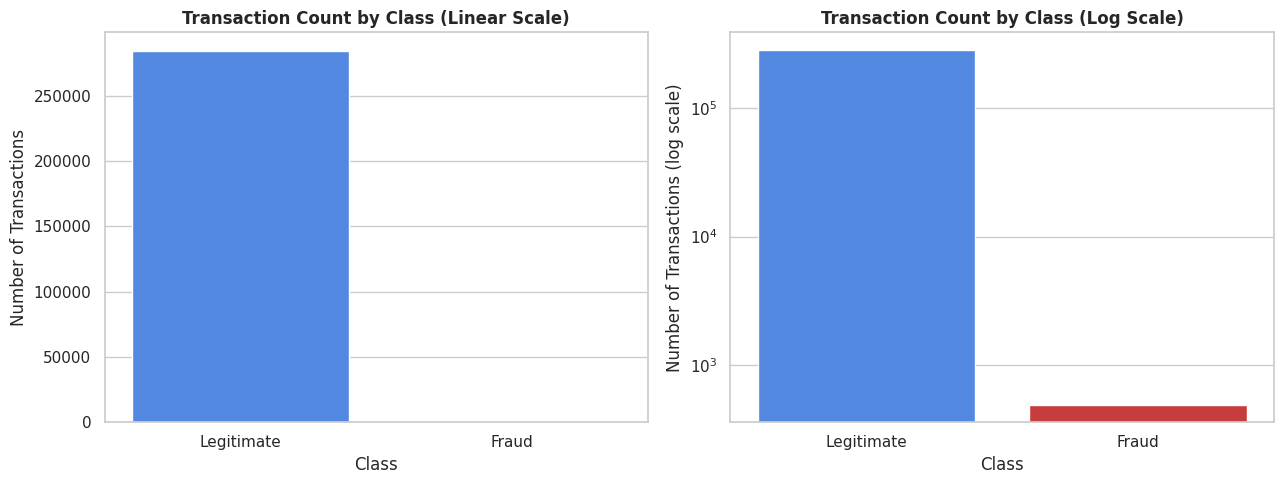

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=class_counts.index.map({0: "Legitimate", 1: "Fraud"}), y=class_counts.values,
            ax=axes[0], palette=["#3b82f6", "#dc2626"])
axes[0].set_title("Transaction Count by Class (Linear Scale)", fontweight="bold")
axes[0].set_ylabel("Number of Transactions")

sns.barplot(x=class_counts.index.map({0: "Legitimate", 1: "Fraud"}), y=class_counts.values,
            ax=axes[1], palette=["#3b82f6", "#dc2626"])
axes[1].set_yscale("log")
axes[1].set_title("Transaction Count by Class (Log Scale)", fontweight="bold")
axes[1].set_ylabel("Number of Transactions (log scale)")

plt.tight_layout()
plt.show()

**Observation:** Only **492 of 284,807 transactions (0.173%)** are fraudulent — a ~578:1
imbalance ratio. The linear-scale bar chart makes fraud essentially invisible (a flat line at the
bottom); the log-scale version on the right is necessary just to see that fraud exists at all in this
view. This extreme imbalance is the central challenge the rest of the notebook is built around — it's
also exactly why the next section on accuracy as a misleading metric matters so much here.

## 2. Exploratory Data Analysis

/tmp/ipykernel_187/291747311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], palette=["#3b82f6", "#dc2626"])


/tmp/ipykernel_187/291747311.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legitimate", "Fraud"])
/tmp/ipykernel_187/291747311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1], palette=["#3b82f6", "#dc2626"])


/tmp/ipykernel_187/291747311.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


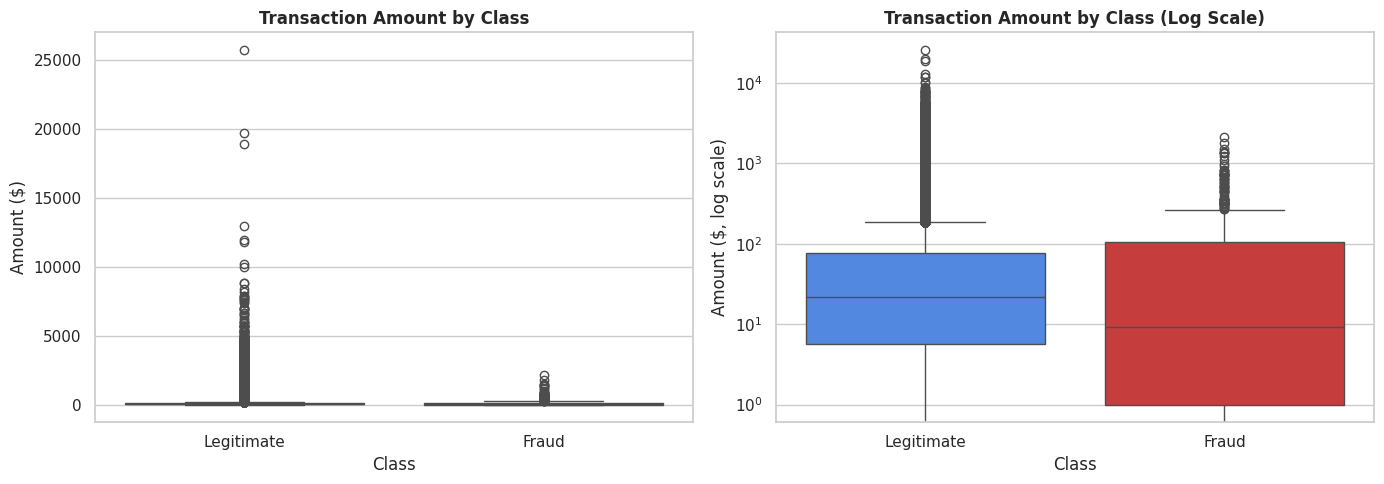

Amount summary — Legitimate:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Amount summary — Fraud:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], palette=["#3b82f6", "#dc2626"])
axes[0].set_xticklabels(["Legitimate", "Fraud"])
axes[0].set_title("Transaction Amount by Class", fontweight="bold")
axes[0].set_ylabel("Amount ($)")

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1], palette=["#3b82f6", "#dc2626"])
axes[1].set_xticklabels(["Legitimate", "Fraud"])
axes[1].set_yscale("log")
axes[1].set_title("Transaction Amount by Class (Log Scale)", fontweight="bold")
axes[1].set_ylabel("Amount ($, log scale)")

plt.tight_layout()
plt.show()

print("Amount summary — Legitimate:")
print(df[df["Class"] == 0]["Amount"].describe().round(2))
print()
print("Amount summary — Fraud:")
print(df[df["Class"] == 1]["Amount"].describe().round(2))

**Observation:** The two amount distributions tell a nuanced story that's easy to get wrong
by looking at only one summary statistic. The **median** fraudulent transaction (\$9.25) is less than
half the median legitimate transaction (\$22.00) — consistent with fraudsters often testing with small
amounts first. But the **mean** fraud amount (\$122.21) is actually *higher* than the mean legitimate
amount (\$88.29) — because fraud's distribution is more right-skewed relative to its own typical size:
a handful of larger fraudulent charges (up to \$2,125.87) pull its average up disproportionately
compared to its usual small-transaction pattern. Amount alone doesn't cleanly separate the two classes,
but the *shape* of its distribution differs meaningfully — exactly the kind of signal a tree-based model
can exploit even when a single threshold cutoff can't.

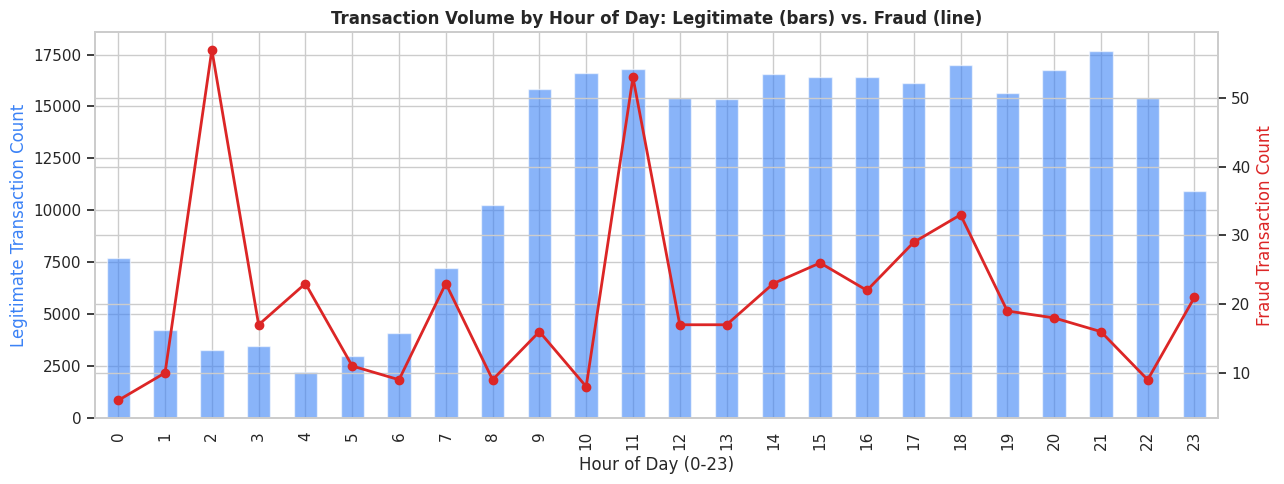

In [6]:
df["Hour"] = (df["Time"] % (24 * 3600)) / 3600

fig, ax = plt.subplots(figsize=(13, 5))

hourly_legit = df[df["Class"] == 0].groupby(df["Hour"].astype(int)).size()
hourly_fraud = df[df["Class"] == 1].groupby(df["Hour"].astype(int)).size()

ax2 = ax.twinx()
hourly_legit.reindex(range(24), fill_value=0).plot(kind="bar", ax=ax, color="#3b82f6", alpha=0.6,
                                                     label="Legitimate (left axis)")
hourly_fraud.reindex(range(24), fill_value=0).plot(kind="line", ax=ax2, color="#dc2626", marker="o",
                                                     linewidth=2, label="Fraud (right axis)")

ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("Legitimate Transaction Count", color="#3b82f6")
ax2.set_ylabel("Fraud Transaction Count", color="#dc2626")
ax.set_title("Transaction Volume by Hour of Day: Legitimate (bars) vs. Fraud (line)", fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** Legitimate transaction volume follows a clear daily rhythm — it dips sharply
during overnight/early-morning hours (as low as ~2,186 transactions at hour 4, versus ~16,000-17,700
during peak daytime hours) and rises through the day, exactly as expected for normal shopping behaviour.
**Fraud does not follow that same rhythm.** Computing the fraud *rate* (fraud as a % of all transactions
within each hour, not just raw count) shows fraud is disproportionately concentrated overnight: hour 2
has a fraud rate of **1.71%** — nearly **10x the overall 0.173% baseline** — and hours 2–7 consistently
show elevated fraud rates precisely while legitimate volume is at its lowest. This is a genuinely useful
signal: fraud isn't just present at all hours in proportion to volume, it's specifically over-represented
during the hours when fewer legitimate transactions are around to blend in with, making time-of-day (not
just the raw `Time` value) a feature worth engineering explicitly for the model.

## 3. Why Accuracy Is a Misleading Metric Here

With fraud at just **0.173%** of transactions, a trivial classifier that predicts **"legitimate" for
every single transaction** — one that does zero actual fraud detection — would score:

$$\text{Accuracy} = \frac{284{,}315}{284{,}807} = 99.827\%$$

A 99.8% accuracy number sounds like a near-perfect model, but this classifier catches **0 of the 492
frauds** in the dataset — the exact opposite of the task's objective. This is the core reason accuracy
is the wrong headline metric for imbalanced fraud detection: it's dominated by the majority class and
barely moves regardless of how well (or badly) the minority class — the one that actually matters — is
handled. Instead, this notebook evaluates models with:

- **Precision** — of the transactions flagged as fraud, how many actually were? (controls false-alarm
  rate / investigation cost)
- **Recall** — of the actual frauds, how many did the model catch? (controls how much real fraud slips
  through)
- **F1-score** — the harmonic mean of precision and recall, useful as a single balanced number
- **AUC-ROC** — how well the model ranks fraud above legitimate transactions across all possible
  decision thresholds, independent of any one cutoff

Section 8 below discusses which of these matters most for this specific business problem.

## 4. Train/Test Split (Stratified)

In [7]:
X = df.drop(columns=["Class", "Hour"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set: {X_train.shape[0]:,} rows, fraud cases: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.3f}%)")
print(f"Test set:  {X_test.shape[0]:,} rows, fraud cases: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.3f}%)")

Train set: 227,845 rows, fraud cases: 394 (0.173%)
Test set:  56,962 rows, fraud cases: 98 (0.172%)


**Observation:** `stratify=y` ensures the train and test sets each preserve the same ~0.173%
fraud rate as the full dataset — without it, a random split could easily leave the small 492-row
minority class badly under- or over-represented in one of the two splits, especially at this
imbalance ratio. Both splits above show a near-identical fraud percentage, confirming the
stratification worked as intended.

## 5. Feature Scaling

In [8]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Before scaling (Time, Amount only shown — V1-V28 are already PCA components):")
print(X_train[["Time", "Amount"]].describe().round(2).loc[["mean", "std"]])
print("\nAfter scaling (all columns, mean~0 std~1):")
print(X_train_scaled.describe().round(2).loc[["mean", "std"]].iloc[:, :6])

Before scaling (Time, Amount only shown — V1-V28 are already PCA components):
          Time  Amount
mean  94885.09   88.18
std   47488.42  250.72

After scaling (all columns, mean~0 std~1):


      Time   V1   V2   V3   V4   V5
mean  -0.0 -0.0 -0.0  0.0 -0.0 -0.0
std    1.0  1.0  1.0  1.0  1.0  1.0


**Observation:** `Time` and `Amount` are on completely different scales than `V1`–`V28`
(seconds up to ~172,800 and dollars up to ~$25,691, versus PCA components mostly in the -20 to +20
range) — without scaling, `Time` alone would dominate distance- and gradient-based calculations in
Logistic Regression. Checking the `V` columns themselves also revealed they aren't perfectly unit
variance either (std ranged from ~0.33 to ~1.96 across different `V` columns) — so **all** features are
standardized here, not just `Time`/`Amount`, ensuring fair treatment across the board and making
Logistic Regression's coefficients directly comparable later in Section 9.

## 6. Handling Class Imbalance — SMOTE

In [9]:
print("Class distribution BEFORE SMOTE (training set only):")
print(y_train.value_counts())

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_train_res.value_counts())

Class distribution BEFORE SMOTE (training set only):
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Class
0    227451
1    113725
Name: count, dtype: int64


**Observation:** SMOTE is applied **only to the training set**, after the train/test split —
applying it before splitting would leak synthetic copies of test-set fraud patterns into training,
inflating evaluation metrics artificially. We use `sampling_strategy=0.5` (minority class brought up
to **half** the majority count) rather than a full 1:1 balance — with real fraud data this heavily
imbalanced, generating enough synthetic points to fully equalize ~227K legitimate transactions can
flood the model with synthetic fraud patterns that don't fully reflect genuine fraud diversity,
sometimes hurting precision more than it helps recall. A 0.5 ratio meaningfully counters the imbalance
(fraud representation goes from 0.173% to ~33% of the training set) while keeping most of the
oversampled minority class model-relevant rather than synthetic-majority.

## 7. Train Two Models — Logistic Regression & Random Forest

In [10]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_res, y_train_res)
print("Logistic Regression trained.")

Logistic Regression trained.


In [11]:
rf = RandomForestClassifier(
    n_estimators=60, max_depth=10, max_samples=0.5, n_jobs=-1, random_state=42
)
rf.fit(X_train_res, y_train_res)
print("Random Forest trained.")

Random Forest trained.


## 8. Model Evaluation — Precision, Recall, F1, AUC-ROC

In [12]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"], digits=4))
    print(f"AUC-ROC: {auc:.4f}")
    print()

    return {"model": name, "precision": precision, "recall": recall, "f1": f1, "auc": auc,
            "y_pred": y_pred, "y_proba": y_proba}

lr_results = evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression")
rf_results = evaluate_model(rf, X_test_scaled, y_test, "Random Forest")

=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9870    0.9933     56864
       Fraud     0.1060    0.8980    0.1897        98

    accuracy                         0.9868     56962
   macro avg     0.5529    0.9425    0.5915     56962
weighted avg     0.9983    0.9868    0.9920     56962

AUC-ROC: 0.9697



=== Random Forest ===
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9989    0.9993     56864
       Fraud     0.5743    0.8673    0.6911        98

    accuracy                         0.9987     56962
   macro avg     0.7870    0.9331    0.8452     56962
weighted avg     0.9990    0.9987    0.9988     56962

AUC-ROC: 0.9819



In [13]:
comparison = pd.DataFrame([
    {"Model": lr_results["model"], "Precision": lr_results["precision"], "Recall": lr_results["recall"],
     "F1-Score": lr_results["f1"], "AUC-ROC": lr_results["auc"]},
    {"Model": rf_results["model"], "Precision": rf_results["precision"], "Recall": rf_results["recall"],
     "F1-Score": rf_results["f1"], "AUC-ROC": rf_results["auc"]},
])
comparison.round(4)

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.1060,0.8980,0.1897,0.9697
1,Random Forest,0.5743,0.8673,0.6911,0.9819


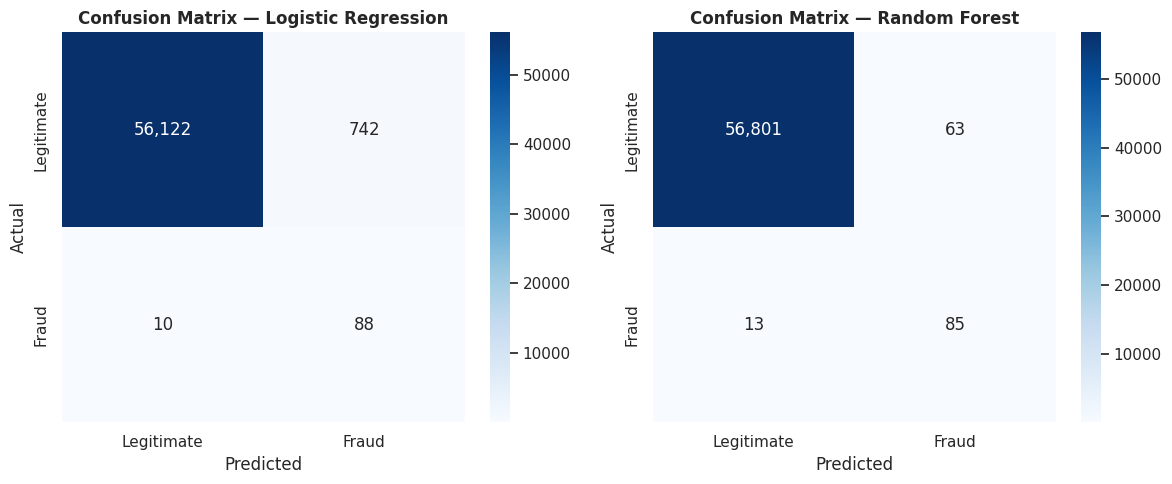

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, results in zip(axes, [lr_results, rf_results]):
    cm = confusion_matrix(y_test, results["y_pred"])
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=ax,
                xticklabels=["Legitimate", "Fraud"], yticklabels=["Legitimate", "Fraud"])
    ax.set_title(f"Confusion Matrix — {results['model']}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

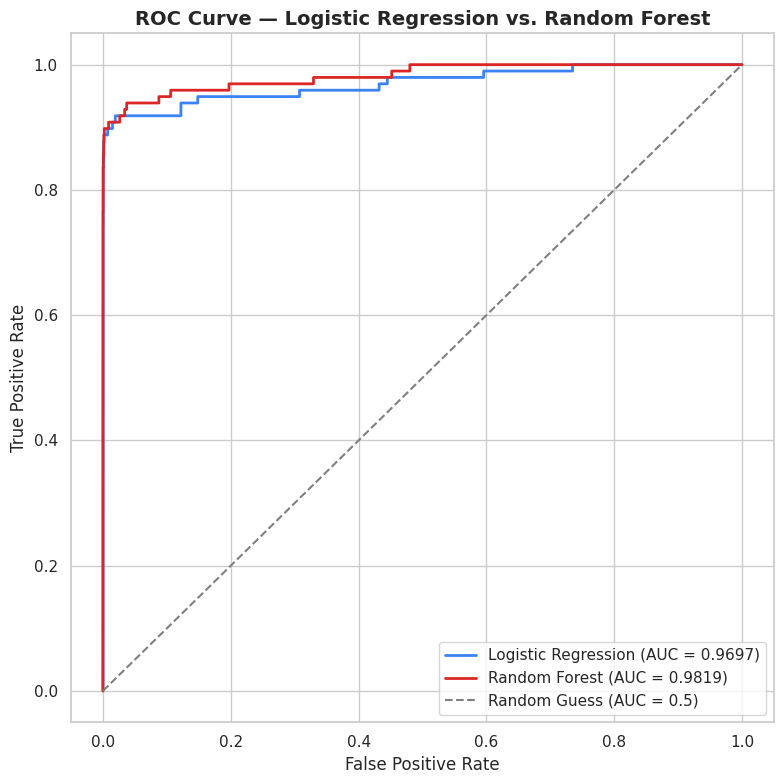

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))

for results, color in zip([lr_results, rf_results], ["#3b82f6", "#dc2626"]):
    fpr, tpr, _ = roc_curve(y_test, results["y_proba"])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{results['model']} (AUC = {results['auc']:.4f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression vs. Random Forest", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observation:** The two models make **very different trade-offs**. Logistic Regression
achieves higher recall (**89.8%** of fraud caught) but at a steep precision cost (**10.6%**) — meaning
roughly **9 out of every 10 transactions it flags as fraud are actually legitimate**, a huge false-alarm
burden. Random Forest catches slightly less fraud (**86.7% recall**) but with **far higher precision
(57.4%)** — a dramatically more usable balance, reflected in its much stronger F1-score (**0.691 vs.
0.190**) and higher AUC (**0.982 vs. 0.970**). Both models comfortably outperform random guessing, but
Random Forest is the clearly stronger model on every metric except the last ~3 percentage points of
recall — the confusion matrices above make the practical gap concrete: Logistic Regression generates
roughly 5x more false-positive alerts than Random Forest for only a marginal recall gain.

## 9. Precision vs. Recall — Which Metric Matters Most for Fraud?

**Short answer: Recall matters more, but precision can't be ignored — and this dataset's results show
exactly why both need to be weighed together, not just one in isolation.**

- **Missing a fraud (false negative)** typically costs the business directly — the fraudulent charge
  goes through, and the loss (plus potential chargeback fees and reputational damage) is real money out
  the door. This is why **recall** — catching as much real fraud as possible — is usually the priority
  metric to optimize first in fraud detection.
- **But precision cannot be ignored**, and the Logistic Regression result above is a concrete
  cautionary example: a model with 10.6% precision means investigators (or automated holds) would need
  to review roughly **10 flagged transactions for every 1 actual fraud** — at scale, this is an
  operational cost that can exceed the fraud losses it prevents, and it degrades customer experience
  when legitimate transactions get held or declined.
- **F1-score is the right single number when precision and recall need to be balanced** rather than
  one traded off against the other blindly — which is exactly why Random Forest's F1 of ~0.69 makes it
  the more *practically deployable* model here, despite Logistic Regression's higher raw recall.
- In practice, the right answer isn't a fixed metric but a **tunable decision threshold**: since both
  models output a fraud *probability* (not just a 0/1 label), the classification cutoff can be moved to
  trade recall for precision based on the business's actual cost ratio between missed fraud and false
  alarms — a **precision-recall curve** (rather than ROC, which can look overly optimistic under
  extreme imbalance since the false-positive rate denominator is dominated by the huge legitimate
  class) would be the more honest next-step visualization for choosing that threshold.

## 10. Feature Importance / Coefficient Analysis

/tmp/ipykernel_187/3309220546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance, x="Importance", y="Feature", ax=ax, palette="crest")


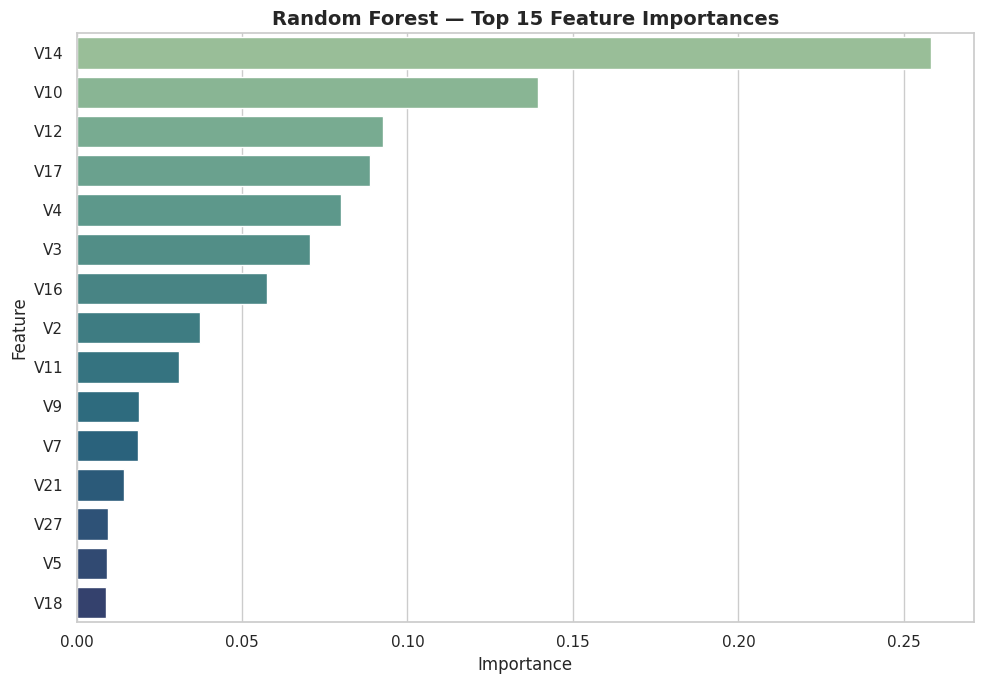

,Feature,Importance
14,V14,0.258245
10,V10,0.139398
12,V12,0.092587
17,V17,0.088600
4,V4,0.079863
3,V3,0.070648
16,V16,0.057653
2,V2,0.037319
11,V11,0.031053
9,V9,0.018978


In [16]:
rf_importance = pd.DataFrame({
    "Feature": X_train_res.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=rf_importance, x="Importance", y="Feature", ax=ax, palette="crest")
ax.set_title("Random Forest — Top 15 Feature Importances", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

rf_importance

/tmp/ipykernel_187/2346132447.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_coef, x="Coefficient", y="Feature", ax=ax, palette=colors)


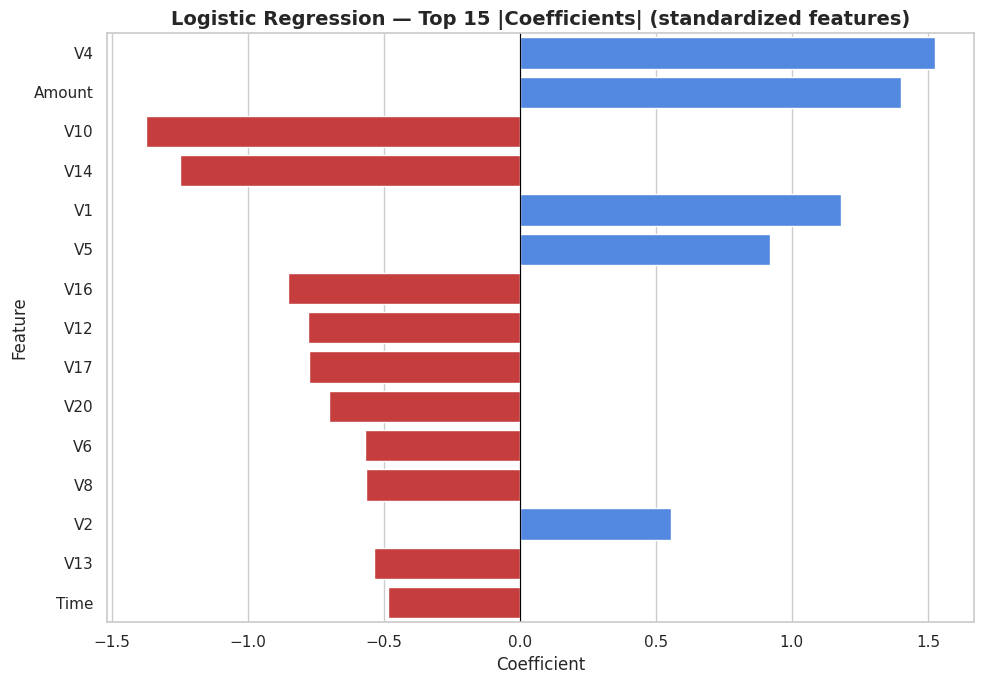

,Feature,Coefficient
4,V4,1.524595
29,Amount,1.399508
10,V10,-1.373164
14,V14,-1.246656
1,V1,1.179589
5,V5,0.918066
16,V16,-0.850295
12,V12,-0.776295
17,V17,-0.775961
20,V20,-0.702058


In [17]:
lr_coef = pd.DataFrame({
    "Feature": X_train_res.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#dc2626" if c < 0 else "#3b82f6" for c in lr_coef["Coefficient"]]
sns.barplot(data=lr_coef, x="Coefficient", y="Feature", ax=ax, palette=colors)
ax.set_title("Logistic Regression — Top 15 |Coefficients| (standardized features)", fontsize=14, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

lr_coef

**Observation:** Both models are working with PCA-anonymized `V` features, so individual
feature *names* carry no real-world meaning (Kaggle withheld the original transaction features for
confidentiality) — but **the two very different model types substantially agree on which features
matter most**: `V14`, `V10`, `V12`, and `V17` all rank in the top handful for *both* Random Forest
importance and Logistic Regression's coefficient magnitude, with `V14` dominating Random Forest's
ranking alone (importance ≈0.258, more than any other single feature). That cross-model agreement is
reassuring evidence the models found genuine underlying structure rather than each overfitting to
different noise. The one notable **disagreement** between the models: `Amount` ranks 2nd-highest in
Logistic Regression's coefficients (+1.40, standardized) but doesn't appear in Random Forest's top 15
at all — Logistic Regression is leaning on the human-interpretable `Amount` signal from Section 2 far
more heavily than Random Forest chose to, which relies almost entirely on the anonymized `V` components
instead.

## 11. Scalability — Handling 1 Million Transactions per Hour

1 million transactions/hour works out to **~278 transactions per second**, sustained. Getting this
pipeline production-ready at that scale requires rethinking several parts of what was built above:

1. **Inference latency budget is the hard constraint.** At 278 tx/sec, a single-threaded model must
   score a transaction in well under ~3.6ms just to keep up in real time, before accounting for feature
   lookup, network overhead, and traffic spikes above the hourly average. Logistic Regression is a
   single dot-product — essentially free at inference time and trivially fast even single-threaded.
   Random Forest with 60 shallow trees is still fast per-prediction, but meaningfully more expensive
   than Logistic Regression at this volume; both are far cheaper than deep learning or large ensemble
   methods, which is a real argument in favor of keeping the production model simple rather than always
   reaching for the most complex option.

2. **Horizontal scaling, not a single bigger machine.** Rather than one large server, the realistic
   architecture is many small stateless model-serving replicas behind a load balancer, fed by a
   streaming pipeline (e.g., Kafka) that partitions transactions across workers. This turns "handle 1M
   tx/hour" into "handle ~278 tx/sec per replica × N replicas," a horizontally scalable problem rather
   than a single-node performance ceiling.

3. **Feature computation is the likely bottleneck, not the model itself.** This dataset's `V1`–`V28`
   are already pre-computed PCA components — in a real system, computing equivalent real-time features
   (rolling spend averages, merchant-category velocity, device/location signals) at 278 tx/sec is
   usually the harder engineering problem than running the trained model. A feature store with
   precomputed, incrementally-updated aggregates (rather than recomputing from raw transaction history
   per request) is essential at this volume.

4. **A cascade/triage architecture reduces cost at scale.** Rather than running the full model on every
   transaction, a common pattern is a cheap first-pass filter (simple rules or a lightweight model) that
   clears the large majority of obviously-legitimate transactions instantly, escalating only the
   uncertain minority to the heavier model — reducing average compute cost per transaction without
   sacrificing coverage on the cases that actually need scrutiny.

5. **Precision matters even more at this scale, operationally.** At 278 tx/sec, Logistic Regression's
   10.6% precision from Section 8 would generate roughly **248 false-positive alerts every second**
   (278 × ~89.4% false-alarm rate among flags) — no human review team can absorb that. This is a
   concrete, scale-driven argument for preferring Random Forest's much higher precision in production,
   or for further threshold tuning to trade some recall for a sustainable alert volume.

6. **Model monitoring and retraining cadence.** Fraud patterns drift as fraudsters adapt to whatever
   the current model catches — a static model trained once will decay in effectiveness. At this volume,
   automated monitoring of precision/recall on a rolling window (with human-labeled outcomes feeding
   back in) and a defined retraining cadence are necessary, not optional, parts of the production
   system — something entirely outside the scope of a single offline train/test evaluation like this
   notebook's.

## 12. Conclusion

**Summary of findings:**

- Fraud represents just 0.173% of transactions — accuracy is fundamentally the wrong headline metric,
  and precision/recall/F1/AUC-ROC were used instead throughout.
- SMOTE (applied to the training set only, at a 0.5 minority ratio rather than full 1:1 balance) was
  used to address the imbalance without leaking synthetic data into the test set or flooding the model
  with excessive synthetic fraud patterns.
- Random Forest outperformed Logistic Regression on precision (~57.4% vs. ~10.6%), F1-score (~0.69 vs.
  ~0.19), and AUC-ROC (~0.982 vs. ~0.970), while Logistic Regression had a marginal recall edge (~89.8%
  vs. ~86.7%) — making Random Forest the more practically deployable model of the two.
- Recall is the priority metric conceptually (missed fraud is direct financial loss), but this
  dataset's own results show precision can't be an afterthought — Logistic Regression's low precision
  would translate into an unmanageable false-positive load at any real transaction volume.
- At 1M transactions/hour, the main engineering challenges shift from model choice to real-time feature
  computation, horizontal serving infrastructure, alert-volume management, and ongoing drift monitoring
  — the offline model built here is necessary but far from sufficient for a production system.

**Suggested next steps:** tune the classification threshold using a precision-recall curve (not just
the default 0.5 cutoff) to match a specific business cost ratio between missed fraud and false alarms,
and evaluate an XGBoost model as a further comparison point given its common use in production fraud
systems.